In [1]:
from toolz.curried import unique
!/truejit/debug/tools/vm-with-compiler --sync-compilation-strategy=jit --dir=/truejit/benchmarks/ffmpeg /truejit/benchmarks/ffmpeg/ffmpeg.wat -y -i /truejit/benchmarks/ffmpeg/in.mov /truejit/benchmarks/ffmpeg/out.mp4 > /tmp/x.txt


ffmpeg version 5.1.git Copyright (c) 2000-2022 the FFmpeg developers
  built with clang version 16.0.0
  configuration: --target-os=none --arch=x86_32 --enable-cross-compile --disable-x86asm --disable-inline-asm --disable-stripping --disable-doc --disable-runtime-cpudetect --disable-autodetect --disable-network --disable-pthreads --disable-w32threads --disable-os2threads --pkg-config-flags=--static --enable-lto --disable-optimizations --enable-debug --nm=../wasi-sdk/bin/nm --ar=../wasi-sdk/bin/ar --ranlib=../wasi-sdk/bin/ranlib --cc=../wasi-sdk/bin/clang --cxx=../wasi-sdk/bin/clang++ --objcc=../wasi-sdk/bin/clang --dep-cc=../wasi-sdk/bin/clang --enable-gpl --enable-libx264 --enable-zlib --extra-cflags=-I../build/include --extra-ldflags=-L../build/lib
  libavutil      57. 30.100 / 57. 30.100
  libavcodec     59. 39.100 / 59. 39.100
  libavformat    59. 29.100 / 59. 29.100
  libavdevice    59.  8.101 / 59.  8.101
  libavfilter     8. 46.100 /  8. 46.100
  libswscale      6.  8.101 /  6. 

In [8]:
!du -sh /tmp/x.txt

53G	/tmp/x.txt


In [10]:
# open file /tmp/profiling.txt
functions = {}
cnt = 0
with open('/tmp/x.txt', 'r') as file:
    for line in file:
        if not line.startswith('$'):
            continue

        # cnt += 1
        # if cnt > 100:
        #     exit(-1)

        line = line.strip()
        pos = line.rfind('(')
        name = line[:pos]
        args = line[pos + 1:-1]

        if name not in functions:
            functions[name] = {}

        if args not in functions[name]:
            functions[name][args] = 0

        functions[name][args] += 1

In [4]:
fn_to_calls = {name: sum(args.cache()) for name, args in functions.items()}
fn_to_unique_args = {name: len(args) for name, args in functions.items()}
fn_to_calls = {k: v for k, v in sorted(fn_to_calls.items(), key=lambda item: item[1], reverse=True)}

# func | #calls | #unique args
for name, calls in fn_to_calls.items():
    print(f'{name} | {calls} | {fn_to_unique_args[name]}')

$abs | 2245883806 | 3140
$memcpy | 87750412 | 33159213
$x264_pixel_satd_8x4 | 61703752 | 3512490
$rnd_avg32 | 44106808 | 10129
$x264_pixel_satd_8x8 | 21628861 | 1200963
$get_ref | 9504422 | 16161
$pixel_hadamard_ac | 8943700 | 8
$macroblock_cache_ref_2_2 | 8630984 | 32
$macroblock_cache_mv_2_2 | 8600313 | 329
$x264_pixel_sad_16x16 | 8259172 | 2646988
$pixel_sub_wxh | 7865099 | 368
$sub4x4_dct | 7628993 | 336
$mc_copy | 7570413 | 2662210
$just_return | 7087818 | 499789
$x264_8_copy_column8 | 5765760 | 4
$x264_8_prefetch_fenc | 5072760 | 1330560
$prefetch_fenc_null | 5072760 | 1330560
$pixel_avg_wxh | 4528311 | 1677601
$mb_load_mv_direct8x8 | 4297651 | 4
$slicetype_mb_cost | 4241160 | 148
$mc_copy_w8 | 4241160 | 1191960
$pixel_avg_8x8 | 3889389 | 1753325
$ssd_plane | 3463008 | 3
$cabac_putbyte | 3388006 | 1
$cabac_encode_renorm | 3360986 | 1
$x264_8_plane_copy_deinterleave_c | 3242776 | 2522518
$x264_pixel_ssd_8x8 | 3028495 | 4
$mc_copy_w16 | 2940376 | 1330564
$bs_pos.2 | 2883094 | 1
$lo

In [2]:
for fn in functions:
    print(functions[fn])

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [14]:
# serialize functions
import pickle

with open('/tmp/functions.pickle', 'wb') as file:
    pickle.dump(functions, file)

In [15]:
!du -sh /tmp/functions.pickle

3.4G	/tmp/functions.pickle


In [1]:
import pickle

functions = None
with open('/tmp/functions.pickle', 'rb') as file:
    functions = pickle.load(file)

print("done")
# assert functions == functions2

done


In [1]:
# open /tmp/profiling.B.txt
traced_function = '$matmul_sub(double (*) [5], double (*) [5], double (*) [5])'
cnt = 0
first = 0
last = 0
with open('/tmp/profiling.rel.A.txt', 'r') as file:
    for line in file:
        if not line.startswith('$'):
            continue
        line = line.strip()

        pos = line.rfind(' ')
        name = line[:pos]
        if name != traced_function:
            continue

        cnt += 1
        print(cnt)
        if cnt == 1:
            timestamp = int(line[pos + 1:])
            print(f'{name} {timestamp}')
            first = timestamp
        if cnt == 100_000_000:
            timestamp = int(line[pos + 1:])
            print(f'{name} {timestamp}')
            last = timestamp
            break
print(f'{last - first}')

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [1]:
!du -sh /tmp/profile.rel.A.txt

19G	/tmp/profile.rel.A.txt


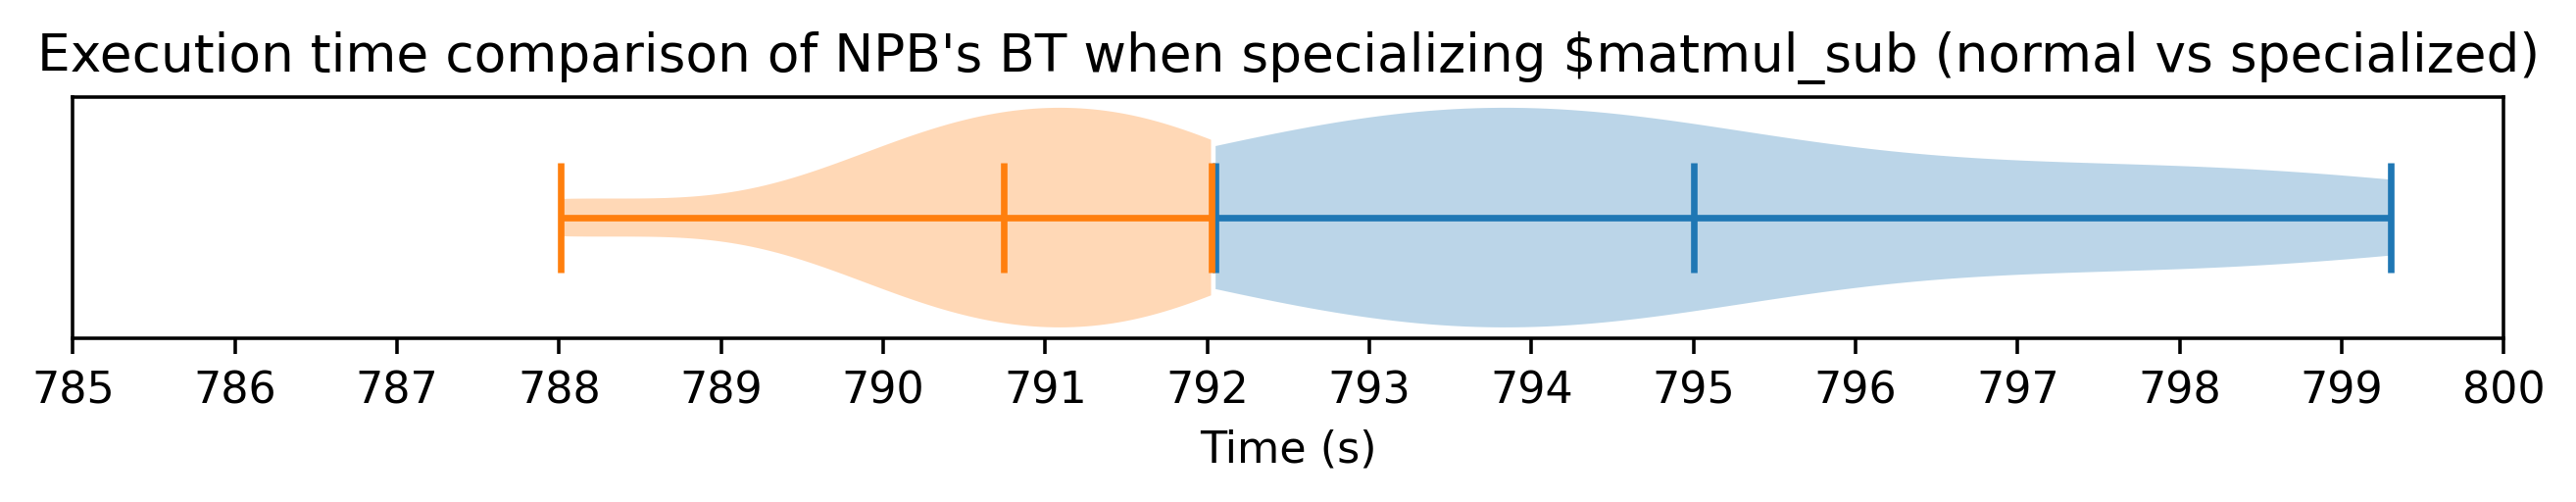

In [46]:
normal = [799302, 792051, 797149, 797974, 793004, 794845, 794534, 793989, 794231, 792929]
normal = [I / 1_000 for I in normal]

specialized = [791953, 790654, 790484, 791188, 788012, 789884, 792023, 791405, 790365, 791464]
specialized = [I / 1_000 for I in specialized]

import matplotlib.pyplot as plt

# figsize=(10, 5), dpi=320
fig, ax = plt.subplots(figsize=(10, 1), dpi=320)

# violin plot
ax.violinplot(normal, showmeans=True, vert=False)
ax.violinplot(specialized, showmeans=True, vert=False)

# remove y labels
ax.set_yticks([])
ax.set_yticklabels([])

# x is from 790 to 800
ax.set_xlim(785, 800)
# set x label every 1s
ax.set_xticks(range(785, 800 + 1, 1))
# x is in seconds
ax.set_xlabel('Time (s)')

# set title
ax.set_title('Execution time comparison of NPB\'s BT when specializing $matmul_sub (normal vs specialized)')

plt.show()

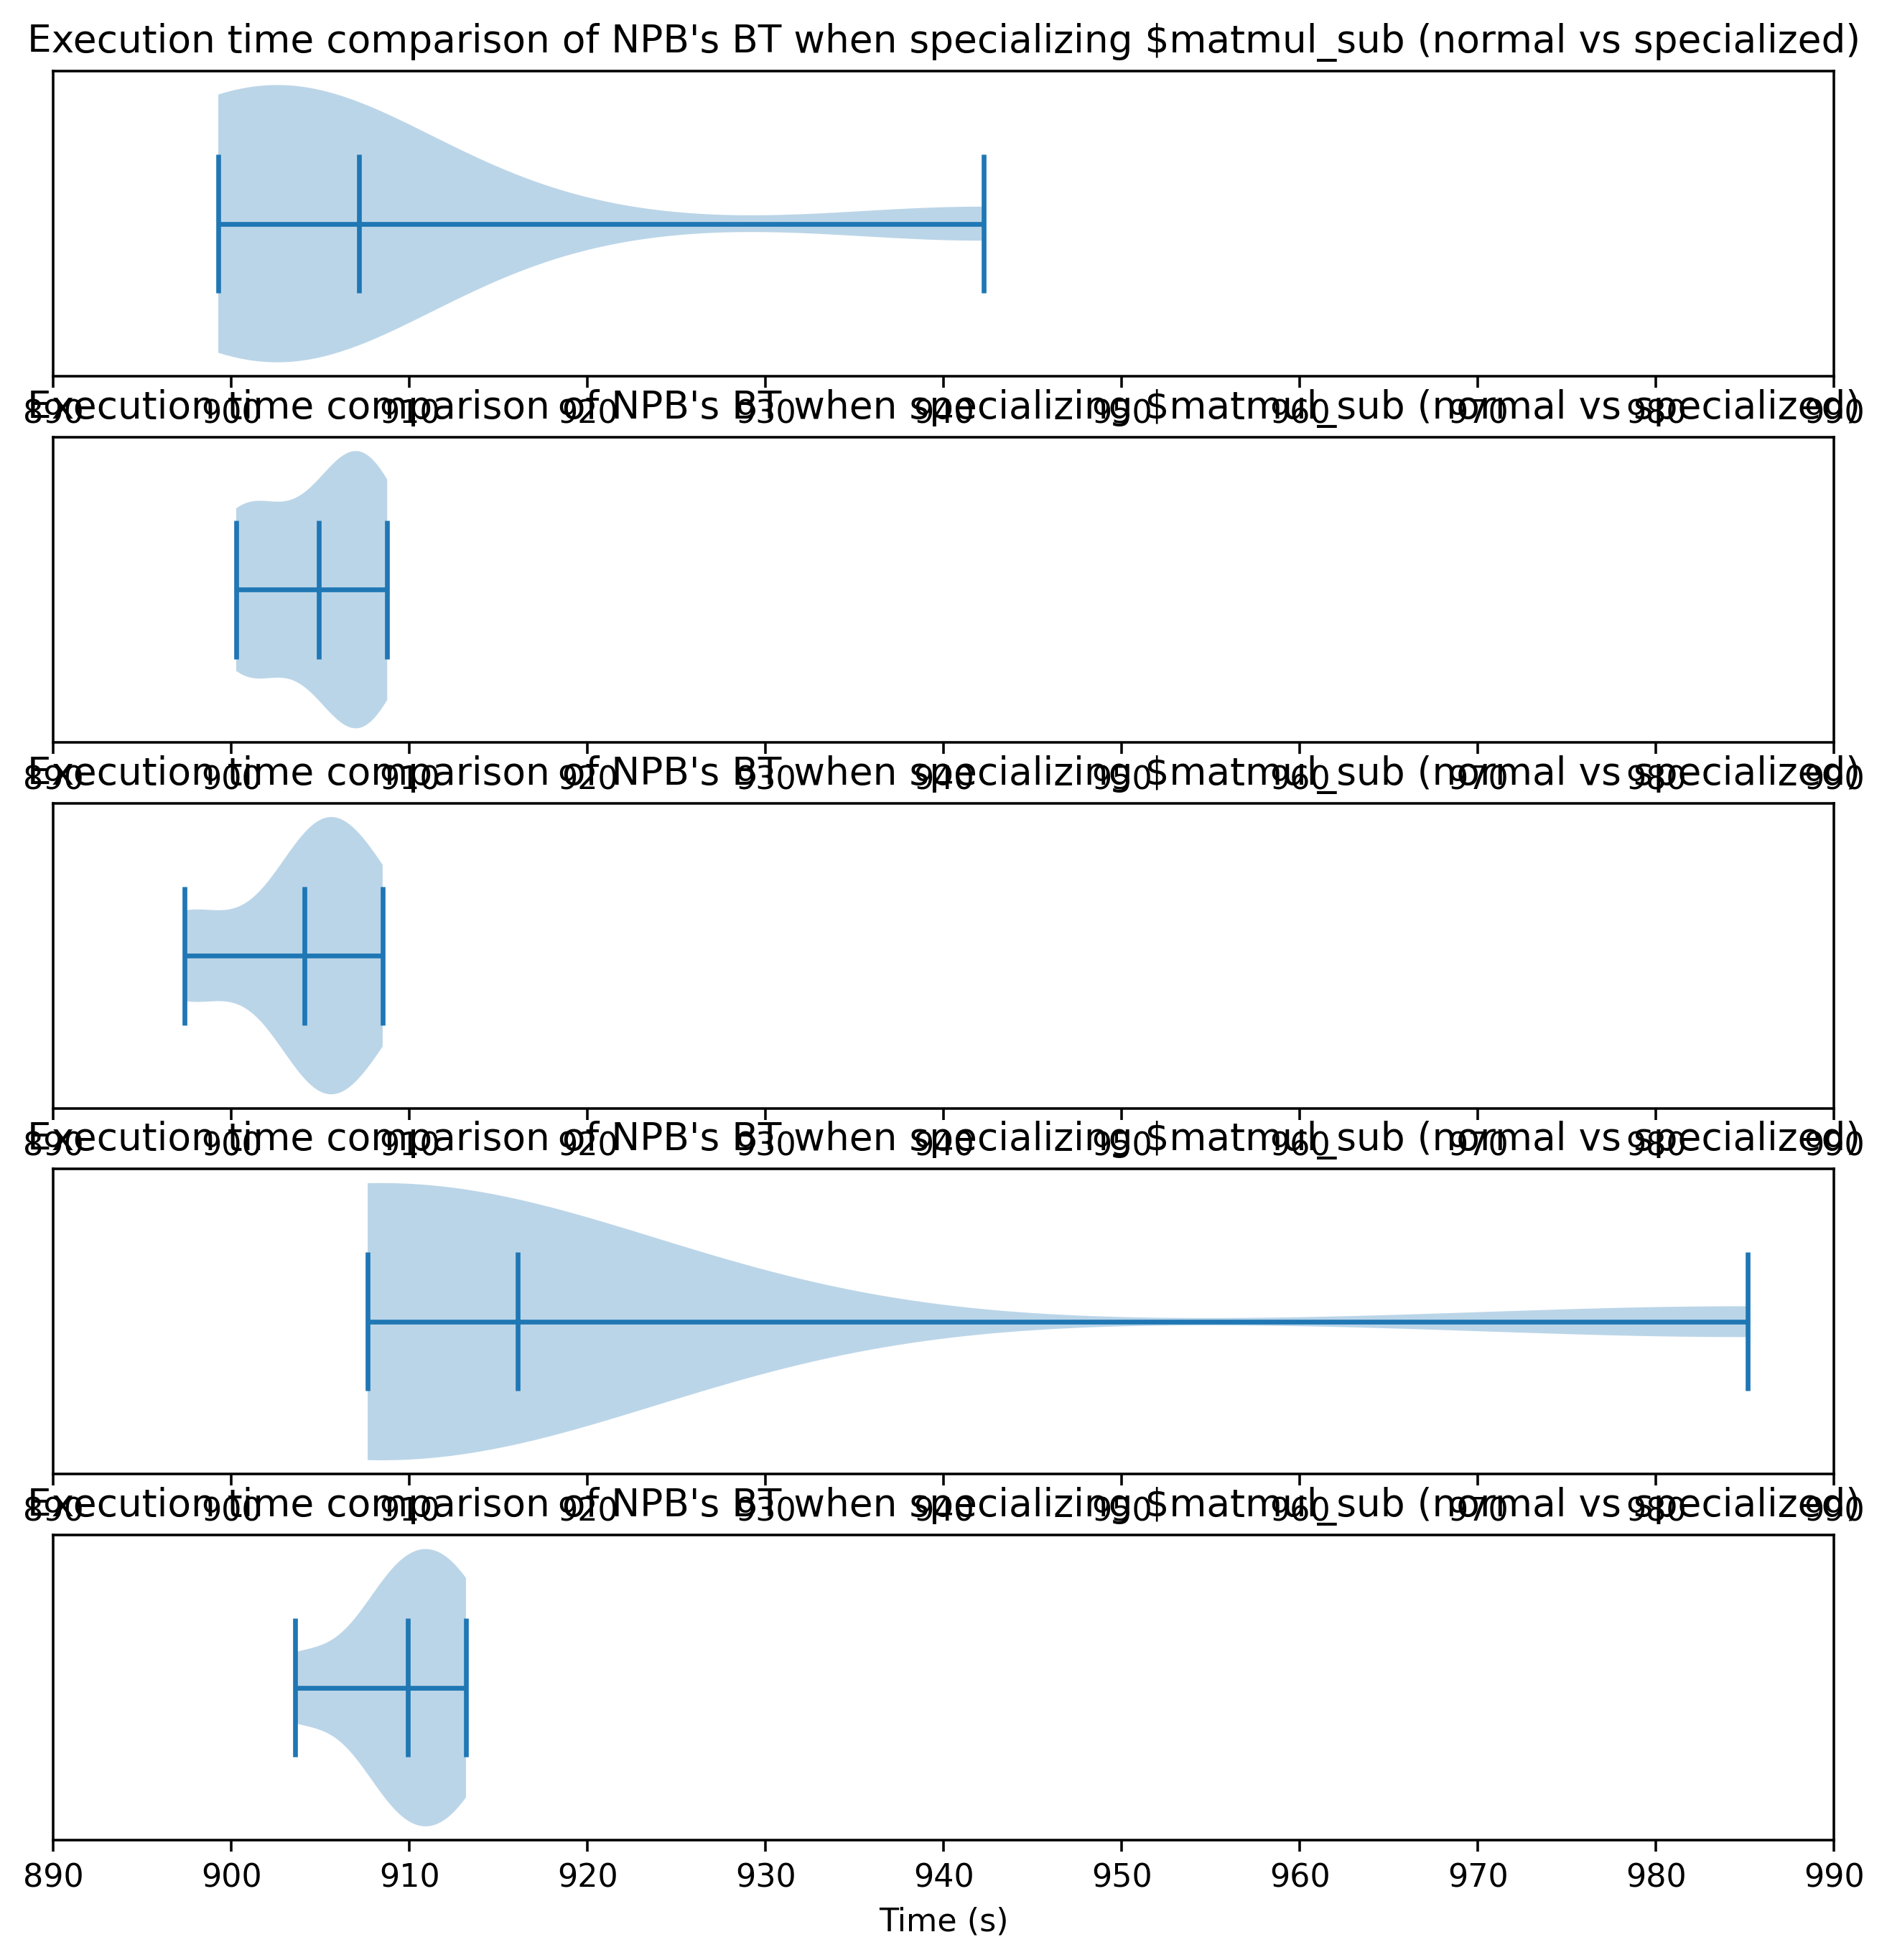

In [6]:
data = [[901329, 899872, 900659, 899257, 942227, 904048, 902924, 913825, 903393, 904289, ],
        [906270, 908466, 900497, 900264, 905851, 903610, 908746, 906799, 907538, 901078, ],
        [905054, 904341, 906255, 897354, 908488, 897578, 905429, 905413, 902934, 908111, ],
        [910718, 909115, 908666, 985139, 907839, 907646, 907915, 907995, 907952, 907944, ],
        [913168, 911845, 912893, 909956, 909100, 908692, 903580]]

data = [[I / 1_000 for I in row] for row in data]

import matplotlib.pyplot as plt

# figsize=(10, 5), dpi=320, 5 subplots
fig, axs = plt.subplots(5, figsize=(10, 10), dpi=320)
for i, ax in enumerate(axs):
    # violin plot
    ax.violinplot(data[i], showmeans=True, vert=False)

    # remove y labels
    ax.set_yticks([])
    ax.set_yticklabels([])

    # x is from 890 to 990
    ax.set_xlim(890, 990)
    # set x label every 10s
    ax.set_xticks(range(890, 990 + 1, 10))
    # x is in seconds
    ax.set_xlabel('Time (s)')

    # set title
    ax.set_title(f'Execution time comparison of NPB\'s BT when specializing $matmul_sub (normal vs specialized)')
plt.show()


In [9]:
import subprocess

num_specializations = [0, 1, 2, 3, 4, 5, 6]
for num_specialization in num_specializations:
    print(f'Starting {num_specialization}')
    out_file = f'/tmp/profiling.MAX_NUM_SPECIALIZATIONS{num_specialization}.txt'
    with open(out_file, 'w') as file:
        pass
    env = {'MAX_NUM_SPECIALIZATIONS': str(num_specialization)}
    for _ in range(10):
        print(f'Iteration {_}')

        out = subprocess.run(['/truejit/debug/tools/vm-with-compiler', '--sync-compilation-strategy=jit',
                              '/users/khordadi/tmp/NPB-CPP/NPB-SER/bin/bt.wasm'], env=env, stdout=subprocess.PIPE,
                             stderr=subprocess.PIPE)
        out = out.stdout.decode('utf-8')

        with open(out_file, 'a') as file:
            file.write(out)
            file.write('\n')

    print(f'Finished {num_specialization}')



Starting 0
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Finished 0
Starting 1
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6


KeyboardInterrupt: 

In [19]:
# !cd /users/khordadi/NPB-CPP/NPB-SER && make bt cg ep 
# is lu mg sp CLASS=B
# for all file ended with .A; move them to /tmp and rename them to .wasm
# !mv /users/khordadi/NPB-CPP/NPB-SER/bin/*.B /tmp
# !for opt in /tmp/*.B; do mv $opt ${opt/.B/.wasm}; done
# !cd /users/khordadi/NPB-CPP/NPB-SER && make bt CLASS=C && mv bin/bt.C /tmp/bt.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make bt CLASS=A && mv bin/bt.A /tmp/bt.A.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make bt CLASS=C && mv bin/bt.C /tmp/bt.C.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make bt CLASS=S && mv bin/bt.S /tmp/bt.S.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make bt CLASS=A && mv bin/bt.A /tmp/bt.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make bt CLASS=S && mv bin/bt.S /tmp/bt.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make is CLASS=C && mv bin/is.C /tmp/is.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make is CLASS=C && mv bin/is.C /tmp/is.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make is CLASS=D && mv bin/is.D /tmp/is.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make ft CLASS=B && mv bin/ft.B /tmp/ft.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make lu CLASS=S && mv bin/lu.S /tmp/lu.wasm
# !cd /users/khordadi/NPB-CPP/NPB-SER && make mg CLASS=B && mv bin/mg.B /tmp/mg.wasm
!cd /users/khordadi/NPB-CPP/NPB-SER && make sp CLASS=C && mv bin/sp.C /tmp/sp.wasm

   =      NAS PARALLEL BENCHMARKS 4.1        =
   =      Serial Versions                    =
   =      C++                                =

cd SP; make CLASS=C
make[1]: Entering directory '/users/khordadi/NPB-CPP/NPB-SER/SP'
make[2]: Entering directory '/users/khordadi/NPB-CPP/NPB-SER/sys'
make[2]: Nothing to be done for 'all'.
make[2]: Leaving directory '/users/khordadi/NPB-CPP/NPB-SER/sys'
../sys/setparams sp C
/opt/wasi-sdk/bin/clang++ -std=c++14  -c -I../common -O3 sp.cpp
/opt/wasi-sdk/bin/clang++ -std=c++14 -O3 -o ../bin/sp.C sp.o ../common/c_print_results.o ../common/c_timers.o ../common/c_wtime.o -lm
make[1]: Leaving directory '/users/khordadi/NPB-CPP/NPB-SER/SP'


In [15]:
# !export TRACE_PARAMS=1; /truejit/debug/tools/vm-with-compiler --sync-compilation-strategy=jit --dir=/tmp /tmp/bt.wasm > /tmp/profiling.txt
# !export SPECIALIZE=0; export TRACE_PARAMS=1; export IR_SIZE=1; /truejit/debug/tools/vm-with-compiler --sync-compilation-strategy=jit /tmp/bt.wasm > /tmp/profiling.txt
# !export SPECIALIZE=0; export TRACE_PARAMS=1; export IR_SIZE=1; /truejit/debug/tools/vm-with-compiler --sync-compilation-strategy=jit /tmp/is.wasm > /tmp/profiling.txt
!export SPECIALIZE=0; export TRACE_PARAMS=1; export IR_SIZE=1; /truejit/debug/tools/vm-with-compiler --sync-compilation-strategy=jit /tmp/ft.wasm > /tmp/profile.txt

^C


In [16]:
!du -sh /tmp/profile.txt

935M	/tmp/profile.txt


In [17]:
# remove color codes
!sed -i "s/\x1b\[[0-9;]*m//g" /tmp/profile.txt

In [13]:
!head -n500 /tmp/profile.txt 
!tail -n10 /tmp/profile.txt 


[ir]   43 $_start

[trace-params] $_start()

[ir]   10 $__wasm_call_ctors

[trace-params] $__wasm_call_ctors()

[ir]   36 $_GLOBAL__sub_I_ft.cpp

[trace-params] $_GLOBAL__sub_I_ft.cpp()

[ir]   14 $malloc

[trace-params] $malloc(i32:1073741824)

[ir] 2183 $dlmalloc

[trace-params] $dlmalloc(i32:1073741824)

[ir]   53 $sbrk

[trace-params] $sbrk(i32:1073741824)

[trace-params] $malloc(i32:8192)

[trace-params] $dlmalloc(i32:8192)

[trace-params] $malloc(i32:2147483648)

[trace-params] $dlmalloc(i32:2147483648)

[trace-params] $malloc(i32:2147483648)

[trace-params] $dlmalloc(i32:2147483648)

[ir]  123 $__main_void

[trace-params] $__main_void()

[ir]   20 $__wasi_args_sizes_get

[trace-params] $__wasi_args_sizes_get(i32:79048, i32:79052)

[trace-params] $malloc(i32:13)

[trace-params] $dlmalloc(i32:13)

[ir]   59 $calloc

[trace-params] $calloc(i32:2, i32:4)

[trace-params] $dlmalloc(i32:8)

[ir]  181 $memset

[trace-params] $memset(i32:1073829152, i32:0, i32:8)

[ir]   19 $__wasi_args

In [7]:
functions = {}
cnt = 0
with open('/tmp/profiling.txt', 'r') as file:
    for line in file:
        # print(line)
        # print(functions)
        # [ir]  616 $lhsinit(double (*) [3][5][5], int)
        if line.startswith('[ir] '):
            line = line.strip()
            # print(line)
            # it's function_size and function_name
            function_size = int(line[len('[ir] '):line.find('$')])
            function_name = line[line.find('$'):]

            # print(line)
            assert function_name not in functions
            functions[function_name] = {'size': function_size, 'calls': 0, 'unique_args': {}}

        # [trace-params] $_start(i32:231, i64:3214, f32:31421, f64:2134)
        elif line.startswith('[trace-params] '):
            line = line.strip()
            name = line[len('[trace-params] '):line.rfind('(')]
            args = line[line.rfind('(') + 1:line.rfind(')')]
            if args == '':  # no args; skip
                continue

            if not name in functions:
                print(f'Function {name} not found')
                # print(line)
                continue
            functions[name]['calls'] += 1
            if args not in functions[name]['unique_args']:
                functions[name]['unique_args'][args] = 0
            functions[name]['unique_args'][args] += 1
        else:
            continue

# remove functions with 0 calls
functions = {name: data for name, data in functions.items() if data['calls'] > 0}

In [24]:
# save functions to file
import pickle

with open('/tmp/bt.A.pickle', 'wb') as file:
    pickle.dump(functions, file)


In [8]:
# print function_name, function_size, calls, unique_args in one line per function
# for name, data in functions.items():
#     print(f'{name} | {data["size"]} | {data["calls"]} | {len(data["unique_args"])}')

# data = name, #calls, #unique_args
data = [[name, data["size"], data["calls"], len(data["unique_args"])] for name, data in functions.items()]
# sort by #calls
data = sorted(data, key=lambda x: x[2], reverse=True)
# print header
print(f'{"Function name":<60} {"Size":>5} {"#calls":>10} {"#unique":>10}')
for name, size, calls, unique_args in data:
    print(f'{name:<60} {size:>5} {calls:>10} {unique_args:>10}')
# good candidates for specialization:
# 1. large #calls
# 2. small #unique_args
# 3. large size

Function name                                                 Size     #calls    #unique
$exp                                                           132     524288          2
$vranlc(int, double*, double, double*)                          80       8192       4097
$memcpy                                                        478        297        297
$__fwritex                                                     146        283        110
$randlc(double*, double)                                        57        156          6
$__rem_pio2                                                    335         92          2
$sin                                                           116         64          2
$cos                                                           114         64          2
$__sin                                                          49         62          4
$__cos                                                          35         62          5
$printf_core         

In [1]:
candidates = [{'name': "$randlc(double*, double)", 'uniq': 4, 'args':[]}, ]
done = len(candidates)
with open('/tmp/profiling.txt', 'r') as file:
    for line in file:
        if line.startswith('[trace-params] '):
            line = line.strip()
            name = line[len('[trace-params] '):line.rfind('(')]
            for c, candidate in enumerate(candidates):
                if name == candidate['name']:
                    args = line[line.rfind('(') + 1:line.rfind(')')]
                    candidates[c]['args'].append(args)
                    if len(candidates[c]['args']) == candidate['uniq']:
                        print(line)
                        done -= 1
                        if done == 0:
                            exit(0)
# remove functions with 0 calls
functions = {name: data for name, data in functions.items() if data['calls'] > 0}

[trace-params] $randlc(double*, double)(i32:73704, f64:0)


NameError: name 'functions' is not defined